# Cross-Staff Calibration Campaign 001

**Notebook:** 01 Exploratory Analysis  
**Survey:** SUR-CAL-2026-001  
**Purpose:** Initial exploration of the validated calibration survey.  
**Author:** Dennis Hazelett

## 1. Introduction

This notebook performs the initial exploratory analysis of the first Kepler cross-staff calibration survey.

The objective is not to build a calibration model, but to become familiar with the observations, verify data integrity, and identify patterns that will guide subsequent analyses.

The canonical survey package remains the authoritative source:

`data/examples/SUR-CAL-2026-001/`

All quantities computed here are derived from those observations.

## 2. Import Packages

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 5)

## 3. Load Survey

In [2]:
# Find the repository root by walking upward until data/ is found.
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'data').exists():
    repo_root = repo_root.parent

survey_dir = repo_root / 'data' / 'examples' / 'SUR-CAL-2026-001'

with open(survey_dir / 'survey.json', encoding='utf-8') as f:
    survey = json.load(f)

observations = pd.read_csv(survey_dir / 'observations.csv')
notes = pd.read_csv(survey_dir / 'notes.csv')

## 4. Survey Summary

In [3]:
print(f"Survey ID: {survey['survey_id']}")
print(f"Survey type: {survey['survey_type']}")
print(f"Scientific question: {survey['scientific_question']}")
print(f"Observers: {', '.join(survey['observer_ids'])}")
print(f"Instruments: {', '.join(survey['instrument_instance_ids'])}")
print(f"\nObservations: {len(observations)}")
print(f"Notes: {len(notes)}")

Survey ID: SUR-CAL-2026-001
Survey type: instrument_calibration
Scientific question: Given a known terrestrial reference, how does the observer–instrument measurement system behave?
Observers: OBS-0001
Instruments: INS-0001

Observations: 27
Notes: 1


## 5. Inspect the Observations

Examine the data for completeness, consistency, unexpected values, and opportunities for further investigation.

In [4]:
observations.head()

,schema_version,survey_id,observation_id,observed_at,observer_id,instrument_instance_id,fiducial_id,staff_reading,notes_id,calibration.target_id,calibration.target_width,calibration.target_distance
0,0.1,SUR-CAL-2026-001,SUR-CAL-2026-001-0001,2026-07-21,OBS-D-HAZELETT,CS-0001,1.00,15.500,NaN,NaN,8.0,120
1,0.1,SUR-CAL-2026-001,SUR-CAL-2026-001-0002,2026-07-21,OBS-D-HAZELETT,CS-0001,1.00,30.750,NaN,NaN,4.0,120
2,0.1,SUR-CAL-2026-001,SUR-CAL-2026-001-0003,2026-07-21,OBS-D-HAZELETT,CS-0001,0.25,31.050,NaN,NaN,1.0,120
3,0.1,SUR-CAL-2026-001,SUR-CAL-2026-001-0004,2026-07-21,OBS-D-HAZELETT,CS-0001,0.25,13.435,NOTE-0001,NaN,2.0,120
4,0.1,SUR-CAL-2026-001,SUR-CAL-2026-001-0005,2026-07-21,OBS-D-HAZELETT,CS-0001,1.00,29.250,NaN,NaN,4.0,120


In [6]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   schema_version               27 non-null     float64
 1   survey_id                    27 non-null     object 
 2   observation_id               27 non-null     object 
 3   observed_at                  27 non-null     object 
 4   observer_id                  27 non-null     object 
 5   instrument_instance_id       27 non-null     object 
 6   fiducial_id                  27 non-null     float64
 7   staff_reading                27 non-null     float64
 8   notes_id                     1 non-null      object 
 9   calibration.target_id        0 non-null      float64
 10  calibration.target_width     27 non-null     float64
 11  calibration.target_distance  27 non-null     int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 2.7+ KB


In [5]:
observations.describe(include="all")

,schema_version,survey_id,observation_id,observed_at,observer_id,instrument_instance_id,fiducial_id,staff_reading,notes_id,calibration.target_id,calibration.target_width,calibration.target_distance
count,2.700000e+01,27,27,27,27,27,27.000000,27.000000,1,0.0,27.000000,27.000000
unique,NaN,1,27,1,1,1,NaN,NaN,1,NaN,NaN,NaN
top,NaN,SUR-CAL-2026-001,SUR-CAL-2026-001-0001,2026-07-21,OBS-D-HAZELETT,CS-0001,NaN,NaN,NOTE-0001,NaN,NaN,NaN
freq,NaN,27,1,27,27,27,NaN,NaN,1,NaN,NaN,NaN
mean,1.000000e-01,NaN,NaN,NaN,NaN,NaN,0.722222,22.440370,NaN,NaN,3.166667,93.481481
std,2.828430e-17,NaN,NaN,NaN,NaN,NaN,0.754261,7.688903,NaN,NaN,2.685431,35.235876
min,1.000000e-01,NaN,NaN,NaN,NaN,NaN,0.250000,11.375000,NaN,NaN,0.500000,48.000000
25%,1.000000e-01,NaN,NaN,NaN,NaN,NaN,0.250000,14.337500,NaN,NaN,1.000000,49.000000
50%,1.000000e-01,NaN,NaN,NaN,NaN,NaN,0.250000,23.625000,NaN,NaN,2.000000,120.000000
75%,1.000000e-01,NaN,NaN,NaN,NaN,NaN,1.000000,30.000000,NaN,NaN,4.000000,120.000000


## 6. Data Integrity Checks

In [7]:
print("Missing values")
display(observations.isna().sum())

print("\nDuplicate observation IDs")
display(observations[observations['observation_id'].duplicated(keep=False)])

Missing values


schema_version                  0
survey_id                       0
observation_id                  0
observed_at                     0
observer_id                     0
instrument_instance_id          0
fiducial_id                     0
staff_reading                   0
notes_id                       26
calibration.target_id          27
calibration.target_width        0
calibration.target_distance     0
dtype: int64


Duplicate observation IDs


,schema_version,survey_id,observation_id,observed_at,observer_id,instrument_instance_id,fiducial_id,staff_reading,notes_id,calibration.target_id,calibration.target_width,calibration.target_distance


## 7. Measurement Distributions

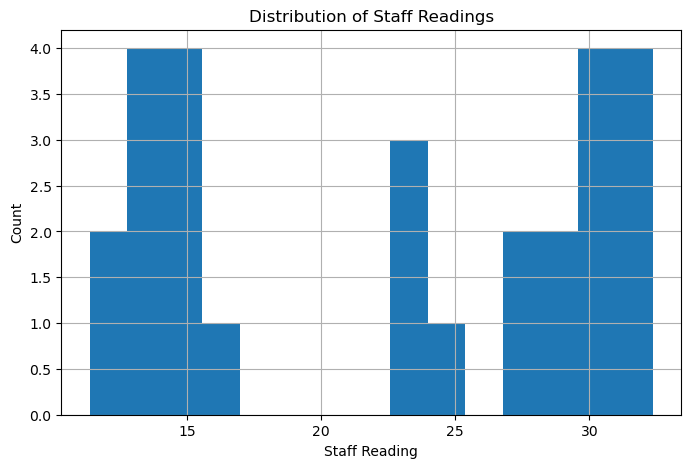

In [8]:
observations['staff_reading'].hist(bins=15)
plt.title('Distribution of Staff Readings')
plt.xlabel('Staff Reading')
plt.ylabel('Count')
plt.show()

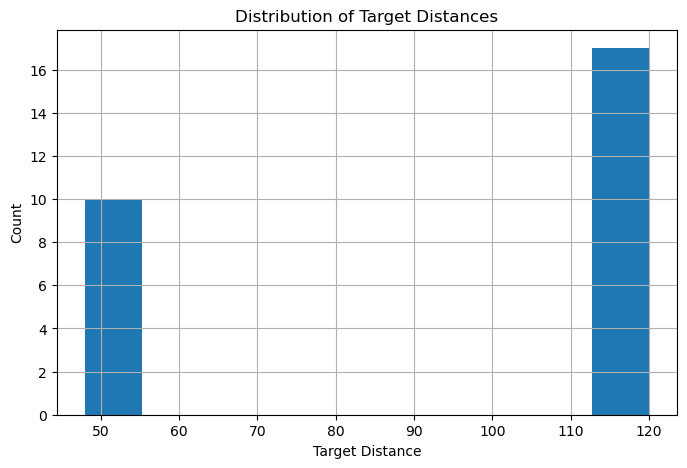

In [10]:
observations['calibration.target_distance'].hist(bins=10)
plt.title('Distribution of Target Distances')
plt.xlabel('Target Distance')
plt.ylabel('Count')
plt.show()

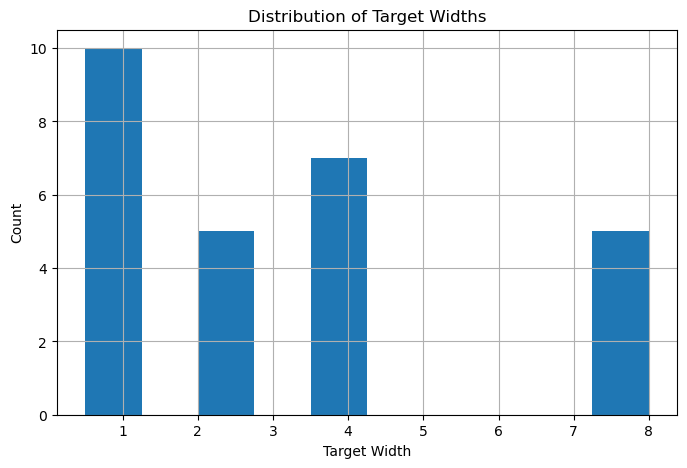

In [11]:
observations['calibration.target_width'].hist(bins=10)
plt.title('Distribution of Target Widths')
plt.xlabel('Target Width')
plt.ylabel('Count')
plt.show()

## 8. Exploratory Scatterplots

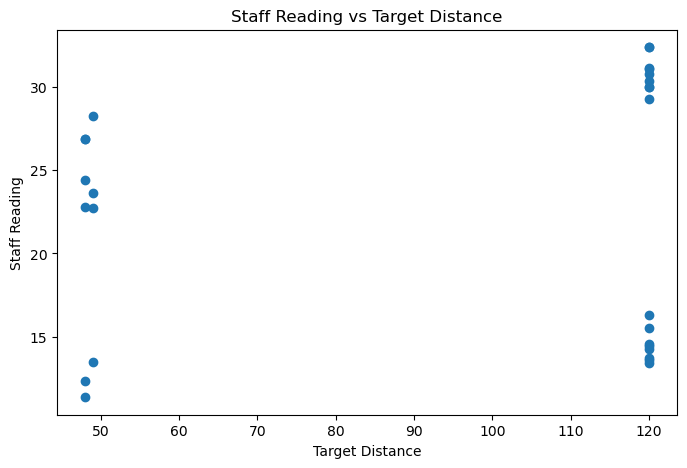

In [13]:
plt.scatter(observations['calibration.target_distance'], observations['staff_reading'])
plt.xlabel('Target Distance')
plt.ylabel('Staff Reading')
plt.title('Staff Reading vs Target Distance')
plt.show()

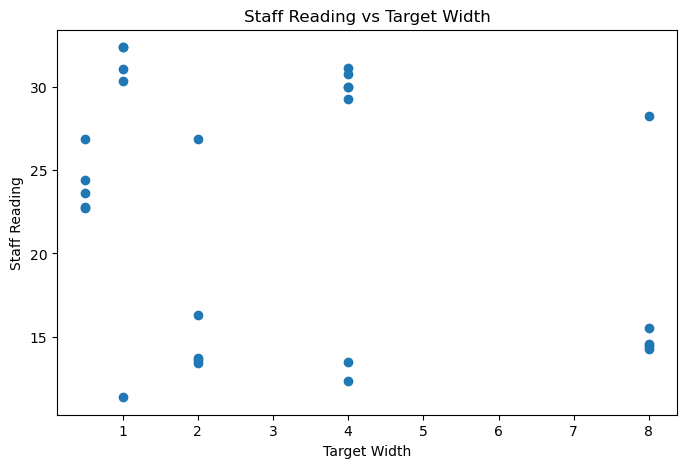

In [14]:
plt.scatter(observations['calibration.target_width'], observations['staff_reading'])
plt.xlabel('Target Width')
plt.ylabel('Staff Reading')
plt.title('Staff Reading vs Target Width')
plt.show()

## 9. Observation Notes

In [15]:
notes

,notes_id,observation_id,note
0,NOTE-0001,SUR-CAL-2026-001-0004,the crosspiece is too close and out of focus


Observation notes may explain unusual measurements or guide subsequent investigation. Review them before identifying observations as outliers.

## 10. Questions Raised

- Do repeated measurements exhibit similar variability?
- Is measurement uncertainty approximately constant?
- Are some fiducials easier to measure than others?
- Does uncertainty increase with target distance?
- Do observer notes explain apparent anomalies?

Add additional questions here as they emerge from the data.